# loading the stable diffusion

In [ ]:
import os
import shutil
import torch
from diffusers import StableDiffusionPipeline

# 1. Detect the best available hardware
if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16  # GPU handles float16 well
    print("Using Hardware: NVIDIA GPU (CUDA)")
elif torch.backends.mps.is_available():
    device = "mps"
    dtype = torch.float32  # Mac Metal (MPS) is most stable with float32
    print("Using Hardware: Apple Silicon (MPS)")
else:
    device = "cpu"
    dtype = torch.float32  # CPU requires float32 (float16 is extremely slow or breaks)
    print("Using Hardware: Standard CPU")

# Change cache path to a local temporary directory for more stable downloads
my_cache_path = "/tmp/models_cache"

# Remove corrupted cache if it exists to force a clean download
if os.path.exists(my_cache_path):
    print(f"Removing corrupted cache directory: {my_cache_path}")
    shutil.rmtree(my_cache_path)

# 2. Load the pipeline with the correct precision
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=dtype,        # <--- Dynamic precision (float16 or float32)
    cache_dir=my_cache_path,
    local_files_only=False
)

# 3. Move to the detected device
pipe = pipe.to(device)

# Optional: Enable memory efficiency if on Mac/CPU to prevent crashing
if device != "cuda":
    pipe.enable_attention_slicing()

print(f"Ready to generate images on {device}!")

Using Hardware: Standard CPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Ready to generate images on cpu!


defining the training loop for the model

In [ ]:
# prompt = "a photo of an astronaut riding a horse on mars"

# # Generate an image
# image = pipe(prompt).images[0]

# # Display the image
# image

In [ ]:
# התקנת ספריית LoRA הרשמית
!pip install -q peft

import torch
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig

# 1. טעינת הרכיבים (כמו קודם)
model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading model components...")
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae")
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet")
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# 2. הקפאת משקולות (Freezing)
# מקפיאים את הכל כדי לאמן רק את ה-LoRA
vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

# 3. הוספת LoRA (התיקון החדש!)
print("Injecting LoRA...")

# הגדרת הקונפיגורציה - במקום לחשב גדלים ידנית, אנחנו אומרים לו איפה להזריק
lora_config = LoraConfig(
    r=4, # Rank (כמו בהצעה)
    lora_alpha=4,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"], # מזריקים לשכבות ה-Attention
)

# הוספת ה-Adapter לתוך ה-UNet
unet.add_adapter(lora_config)

# העברה ל-GPU
vae.to(device)
text_encoder.to(device)
unet.to(device)

print("✅ Model is ready with PEFT LoRA injected!")

Loading model components...
Injecting LoRA...
✅ Model is ready with PEFT LoRA injected!


Mounted at /content/drive
✅ Path found! Loading images from: /content/drive/MyDrive/ Generative Models Course/images
✅ Found 20 images. Displaying sample...


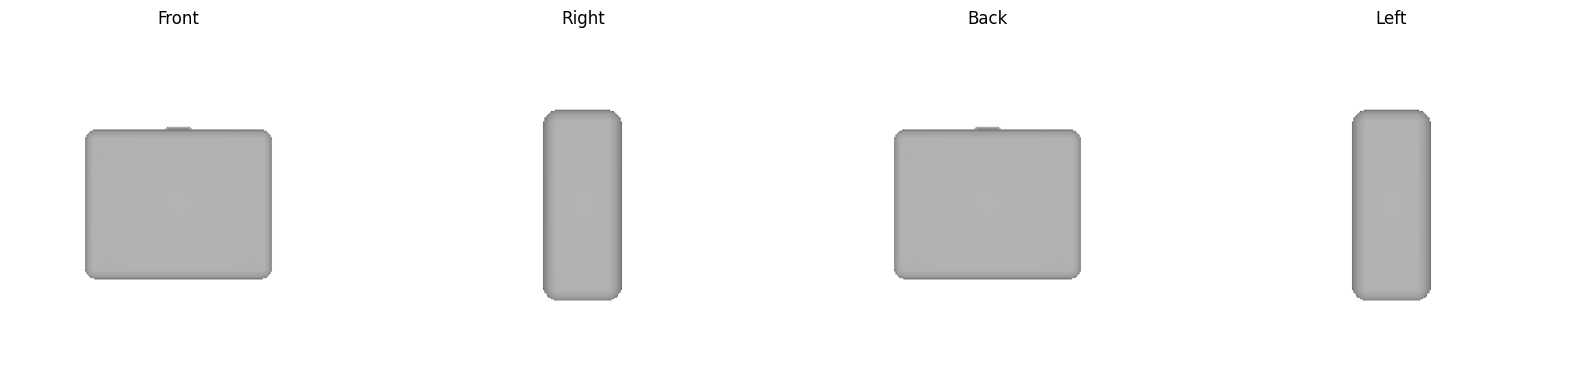

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive

# 1. חיבור לדרייב
drive.mount('/content/drive', force_remount=True)

# 2. הגדרה מחדש של ה-Class (כדי למנוע NameError)
# המחשב חייב להכיר את זה שוב אחרי הריסטארט
class MultiViewDataset(Dataset):
    def __init__(self, root_dir, size=512):
        self.root_dir = root_dir
        # מסנן רק קבצי תמונה (PNG/JPG) ומתעלם מתיקיות נסתרות
        self.files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.size = size

        self.transforms = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        img_path = os.path.join(self.root_dir, file_name)

        try:
            grid_image = Image.open(img_path).convert("RGB")
        except:
            print(f"Error opening image: {img_path}")
            # מחזיר תמונה שחורה במקרה של שגיאה כדי לא לקרוס
            return {"pixel_values": torch.zeros(4, 3, self.size, self.size), "text": "error"}

        W, H = grid_image.size
        w, h = W // 2, H // 2

        # חיתוך ל-4 חלקים
        front = grid_image.crop((0, 0, w, h))
        right = grid_image.crop((w, 0, W, h))
        back  = grid_image.crop((0, h, w, H))
        left  = grid_image.crop((w, h, W, H))

        views_tensors = [self.transforms(v) for v in [front, right, back, left]]
        pixel_values = torch.stack(views_tensors)

        # ניסיון טעינת טקסט
        txt_path = img_path.replace('.png', '.txt').replace('.jpg', '.txt')
        prompt = "A 3D object view"
        if os.path.exists(txt_path):
            with open(txt_path, 'r') as f:
                prompt = f.read().strip()

        return {"pixel_values": pixel_values, "text": prompt}

# --- כאן את צריכה להדביק את הנתיב שהעתקת ---
# דוגמה לאיך זה אמור להיראות: "/content/drive/MyDrive/Generative Models Course/images"
# תמחקי את מה שיש בתוך הגרשיים ותדביקי את שלך:
data_path = "/content/drive/MyDrive/ Generative Models Course/images"

# 3. בדיקה שהנתיב תקין והצגה
if os.path.exists(data_path):
    print(f"✅ Path found! Loading images from: {data_path}")
    # Suggested change: Reduce size for lower memory usage. For example, change 512 to 256.
    dataset = MultiViewDataset(root_dir=data_path, size=256) # Changed from 512 to 256

    if len(dataset) > 0:
        print(f"✅ Found {len(dataset)} images. Displaying sample...")

        # הצגת דוגמה (לוקחים את האינדקס ה-2, כלומר התמונה השלישית)
        # אם יש פחות מ-2 תמונות, ניקח את הראשונה (0)
        idx_to_show = 1 if len(dataset) > 1 else 0

        sample = dataset[idx_to_show]
        imgs = sample["pixel_values"]

        def show_t(t): return (t * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        titles = ["Front", "Right", "Back", "Left"]
        for i, ax in enumerate(axes):
            ax.imshow(show_t(imgs[i]))
            ax.set_title(titles[i])
            ax.axis("off")
        plt.show()
    else:
        print("⚠️ The folder exists, but it's empty or contains no PNG/JPG files.")
else:
    print(f"❌ Error: The path '{data_path}' does not exist.")
    print("👉 Please use the folder icon on the left to find 'images', right-click -> Copy path, and paste it above.")

In [ ]:
import torch.nn.functional as F
from torch.utils.data import DataLoader

from tqdm.auto import tqdm

# --- הגדרות אימון ---
num_train_steps = 50
learning_rate = 1e-4

# --- התיקון לאופטימייזר ---
# אנחנו אוספים רק את הפרמטרים שפתוחים לאימון (רק ה-LoRA)
trainable_params = list(filter(lambda p: p.requires_grad, unet.parameters()))
optimizer = torch.optim.AdamW(trainable_params, lr=learning_rate)

print(f"Training {len(trainable_params)} parameter tensors.")

# הכנת הדאטה-לואדר
train_dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

# Suggested change: Enable gradient checkpointing to save memory during backpropagation
unet.enable_gradient_checkpointing()

print("🚀 Starting Training Loop...")

unet.train()
progress_bar = tqdm(range(num_train_steps))
global_step = 0

for epoch in range(10):
    for batch in train_dataloader:
        if global_step >= num_train_steps:
            break

        # 1. הכנת התמונות
        pixel_values = batch["pixel_values"].to(device)
        b, v, c, h, w = pixel_values.shape
        images = pixel_values.view(b * v, c, h, w)

        # 2. המרה ל-Latents
        latents = vae.encode(images).latent_dist.sample()
        latents = latents * 0.18215

        # 3. הוספת רעש
        noise = torch.randn_like(latents)
        bsz = latents.shape[0]
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps, (bsz,), device=device
        ).long()
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # 4. הכנת הטקסט
        text_input = tokenizer(
            batch["text"],
            padding="max_length",
            max_length=tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt"
        ).input_ids.to(device)

        encoder_hidden_states = text_encoder(text_input)[0]
        encoder_hidden_states = encoder_hidden_states.repeat_interleave(v, dim=0)

        # 5. ניחוש והפסד
        noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
        loss = F.mse_loss(noise_pred, noise, reduction="mean")

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        progress_bar.update(1)
        progress_bar.set_description(f"Loss: {loss.item():.4f}")
        global_step += 1

print("\n✅ Training finished successfully!")

Training 256 parameter tensors.
🚀 Starting Training Loop...


  0%|          | 0/50 [00:00<?, ?it/s]